In [0]:
customers_df = spark.read.csv(
    '/Volumes/capstone_05/default/capstone_vol_02/customers.csv',
    header=True,
    inferSchema=True
)

products_df = spark.read.csv(
    '/Volumes/capstone_05/default/capstone_vol_02/products.csv',
    header=True,
    inferSchema=True
)

orders_df = spark.read.csv(
    '/Volumes/capstone_05/default/capstone_vol_02/orders.csv',
    header=True,
    inferSchema=True
)

preferences_df = spark.read.option(
    "multiLine",
    "true"
).json(
    '/Volumes/capstone_05/default/capstone_vol_02/customer_preferences.json'
)

In [0]:
customers_df.printSchema()
products_df.printSchema()
orders_df.printSchema()
preferences_df.printSchema()

root
 |-- customer_id: string (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- customer_type: string (nullable = true)

root
 |-- product_id: string (nullable = true)
 |-- product_name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- unit_price: integer (nullable = true)

root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- product_id: string (nullable = true)
 |-- order_date: date (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- status: string (nullable = true)

root
 |-- customer_id: string (nullable = true)
 |-- loyalty: struct (nullable = true)
 |    |-- points: long (nullable = true)
 |    |-- tier: string (nullable = true)
 |-- preferred_channel: string (nullable = true)



In [0]:
customers_df.write \
    .format("delta") \
    .mode("overwrite") \
    .save('/Volumes/capstone_05/default/capstone_vol_02/bronze/customers')

products_df.write \
    .format("delta") \
    .mode("overwrite") \
    .save('/Volumes/capstone_05/default/capstone_vol_02/bronze/products')

orders_df.write \
    .format("delta") \
    .mode("overwrite") \
    .save('/Volumes/capstone_05/default/capstone_vol_02/bronze/orders')

preferences_df.write \
    .format("delta") \
    .mode("overwrite") \
    .save('/Volumes/capstone_05/default/capstone_vol_02/bronze/customer_preferences')

In [0]:
from pyspark.sql.functions import * 

def null_checker(df):
    df.select(*[count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).show()

    
null_checker(customers_df)
null_checker(products_df)
null_checker(orders_df)
null_checker(preferences_df)

+-----------+-------------+----+-----+-------------+
|customer_id|customer_name|city|state|customer_type|
+-----------+-------------+----+-----+-------------+
|          0|            0|   0|    0|            0|
+-----------+-------------+----+-----+-------------+

+----------+------------+--------+----------+
|product_id|product_name|category|unit_price|
+----------+------------+--------+----------+
|         0|           0|       0|         0|
+----------+------------+--------+----------+

+--------+-----------+----------+----------+--------+------+
|order_id|customer_id|product_id|order_date|quantity|status|
+--------+-----------+----------+----------+--------+------+
|       0|          0|         0|         0|       0|     0|
+--------+-----------+----------+----------+--------+------+

+-----------+-------+-----------------+
|customer_id|loyalty|preferred_channel|
+-----------+-------+-----------------+
|          0|      0|                0|
+-----------+-------+----------------

In [0]:
flat_preferences_df = preferences_df.select(
    'customer_id',
    'preferred_channel',
    col('loyalty.tier').alias('tier'),
    col('loyalty.points').alias('points')
)

flat_preferences_df.show()

+-----------+-----------------+--------+------+
|customer_id|preferred_channel|    tier|points|
+-----------+-----------------+--------+------+
|       C101|           Online|    Gold|  1200|
|       C102|            Store|  Silver|   700|
|       C104|           Online|Platinum|  2200|
|       C108|       Mobile App|    Gold|  1500|
+-----------+-----------------+--------+------+



In [0]:
full_df = customers_df.alias('c') \
    .join(
        orders_df.alias('o'),
        on='customer_id',
        how='inner'
    ) \
    .join(
        products_df.alias('p'),
        on='product_id',
        how='inner'
    ) \
    .join(
        flat_preferences_df.alias('f'),
        on='customer_id',
        how='left'
    )

full_df.show()

+-----------+----------+-------------+---------+-----------+-------------+--------+----------+--------+---------+------------+-----------+----------+-----------------+--------+------+
|customer_id|product_id|customer_name|     city|      state|customer_type|order_id|order_date|quantity|   status|product_name|   category|unit_price|preferred_channel|    tier|points|
+-----------+----------+-------------+---------+-----------+-------------+--------+----------+--------+---------+------------+-----------+----------+-----------------+--------+------+
|       C101|      P101| Rahul Sharma|Hyderabad|  Telangana|      Premium|   O1001|2026-06-01|       1|Completed|      Laptop|Electronics|     65000|           Online|    Gold|  1200|
|       C102|      P102|  Priya Reddy|Bangalore|  Karnataka|      Regular|   O1002|2026-06-01|       2|Completed|      Mobile|Electronics|     25000|            Store|  Silver|   700|
|       C103|      P103|   Amit Kumar|   Mumbai|Maharashtra|      Regular|   O10

In [0]:
full_df = full_df.withColumn(
    'revenue',
    col('quantity') * col('unit_price')
).withColumn(
    'order_month',
    month(col('order_date'))
).withColumn(
    'customer_segment',
    when(col('customer_type') == 'Premium', 'High Value')
    .when(col('customer_type') == 'Regular', 'Standard Value')
    .otherwise('Other')
)

full_df.show()

+-----------+----------+-------------+---------+-----------+-------------+--------+----------+--------+---------+------------+-----------+----------+-----------------+--------+------+-------+-----------+----------------+
|customer_id|product_id|customer_name|     city|      state|customer_type|order_id|order_date|quantity|   status|product_name|   category|unit_price|preferred_channel|    tier|points|revenue|order_month|customer_segment|
+-----------+----------+-------------+---------+-----------+-------------+--------+----------+--------+---------+------------+-----------+----------+-----------------+--------+------+-------+-----------+----------------+
|       C101|      P101| Rahul Sharma|Hyderabad|  Telangana|      Premium|   O1001|2026-06-01|       1|Completed|      Laptop|Electronics|     65000|           Online|    Gold|  1200|  65000|          6|      High Value|
|       C102|      P102|  Priya Reddy|Bangalore|  Karnataka|      Regular|   O1002|2026-06-01|       2|Completed|   

In [0]:
flat_preferences_df.write \
    .format("delta") \
    .mode("overwrite") \
    .save('/Volumes/capstone_05/default/capstone_vol_02/silver/customer_preferences')

full_df.write \
    .format("delta") \
    .mode("overwrite") \
    .save('/Volumes/capstone_05/default/capstone_vol_02/silver/customer_sales')

In [0]:
customers_df.createOrReplaceTempView("customers")

products_df.createOrReplaceTempView("products")

orders_df.createOrReplaceTempView("orders")

flat_preferences_df.createOrReplaceTempView("customer_preferences")

full_df.createOrReplaceTempView("customer_sales")

In [0]:
%sql
SELECT
    SUM(revenue) AS total_revenue
FROM customer_sales;

total_revenue
336000


In [0]:
%sql
SELECT
    city,
    SUM(revenue) AS total_revenue
FROM customer_sales
GROUP BY city
ORDER BY total_revenue DESC;

city,total_revenue
Hyderabad,135000
Delhi,89000
Bangalore,50000
Mumbai,21000
Chennai,18000
Kochi,15000
Pune,8000


In [0]:
%sql
SELECT
    category,
    SUM(revenue) AS total_revenue
FROM customer_sales
GROUP BY category
ORDER BY total_revenue DESC;

category,total_revenue
Electronics,250000
Furniture,45000
Fashion,41000


In [0]:
%sql
SELECT
    customer_id,
    customer_name,
    SUM(revenue) AS total_revenue
FROM customer_sales
GROUP BY customer_id, customer_name
ORDER BY total_revenue DESC
LIMIT 5;

customer_id,customer_name,total_revenue
C101,Rahul Sharma,90000
C104,Sneha Patel,89000
C102,Priya Reddy,50000
C107,Arjun Verma,45000
C103,Amit Kumar,21000


In [0]:
%sql
SELECT *
FROM orders
WHERE status = 'Completed';

order_id,customer_id,product_id,order_date,quantity,status
O1001,C101,P101,2026-06-01,1,Completed
O1002,C102,P102,2026-06-01,2,Completed
O1004,C104,P104,2026-06-02,2,Completed
O1006,C106,P106,2026-06-03,1,Completed
O1007,C107,P107,2026-06-04,1,Completed
O1008,C108,P108,2026-06-04,5,Completed
O1009,C101,P102,2026-06-05,1,Completed
O1010,C104,P101,2026-06-05,1,Completed


In [0]:
from pyspark.sql.window import Window as win

product_revenue_df = full_df.groupBy(
    'product_id',
    'product_name',
    'category'
).agg(
    sum('revenue').alias('total_revenue')
)

win_spec = win.orderBy(col('total_revenue').desc())

product_rank_df = product_revenue_df.withColumn(
    'rank',
    rank().over(win_spec)
)

product_rank_df.show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+----------+------------+-----------+-------------+----+
|product_id|product_name|   category|total_revenue|rank|
+----------+------------+-----------+-------------+----+
|      P101|      Laptop|Electronics|       130000|   1|
|      P102|      Mobile|Electronics|        75000|   2|
|      P107|          TV|Electronics|        45000|   3|
|      P104|       Table|  Furniture|        24000|   4|
|      P103|       Chair|  Furniture|        21000|   5|
|      P105|       Shoes|    Fashion|        18000|   6|
|      P108|         Bag|    Fashion|        15000|   7|
|      P106|       Watch|    Fashion|         8000|   8|
+----------+------------+-----------+-------------+----+



/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
customer_revenue_df = full_df.groupBy(
    'customer_id',
    'customer_name'
).agg(
    sum('revenue').alias('total_revenue')
)

win_spec = win.orderBy(col('total_revenue').desc())

customer_rank_df = customer_revenue_df.withColumn(
    'rank',
    rank().over(win_spec)
)

customer_rank_df.show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-----------+-------------+-------------+----+
|customer_id|customer_name|total_revenue|rank|
+-----------+-------------+-------------+----+
|       C101| Rahul Sharma|        90000|   1|
|       C104|  Sneha Patel|        89000|   2|
|       C102|  Priya Reddy|        50000|   3|
|       C107|  Arjun Verma|        45000|   4|
|       C103|   Amit Kumar|        21000|   5|
|       C105|   Farhan Ali|        18000|   6|
|       C108|   Meera Nair|        15000|   7|
|       C106|   Neha Singh|         8000|   8|
+-----------+-------------+-------------+----+



/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
top_3_customers_df = customer_revenue_df.withColumn(
    'rank',
    rank().over(win_spec)
).filter(
    col('rank') <= 3
)

top_3_customers_df.show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+-----------+-------------+-------------+----+
|customer_id|customer_name|total_revenue|rank|
+-----------+-------------+-------------+----+
|       C101| Rahul Sharma|        90000|   1|
|       C104|  Sneha Patel|        89000|   2|
|       C102|  Priya Reddy|        50000|   3|
+-----------+-------------+-------------+----+



/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
category_product_df = full_df.groupBy(
    'product_id',
    'product_name',
    'category'
).agg(
    sum('revenue').alias('total_revenue')
)

win_spec = win.partitionBy(
    'category'
).orderBy(
    col('total_revenue').desc()
)

top_product_df = category_product_df.withColumn(
    'rank',
    rank().over(win_spec)
).filter(
    col('rank') == 1
)

top_product_df.show()

+----------+------------+-----------+-------------+----+
|product_id|product_name|   category|total_revenue|rank|
+----------+------------+-----------+-------------+----+
|      P101|      Laptop|Electronics|       130000|   1|
|      P105|       Shoes|    Fashion|        18000|   1|
|      P104|       Table|  Furniture|        24000|   1|
+----------+------------+-----------+-------------+----+



In [0]:
daily_revenue_df = full_df.groupBy(
    'order_date'
).agg(
    sum('revenue').alias('daily_revenue')
)

win_spec = win.orderBy(
    'order_date'
).rowsBetween(
    win.unboundedPreceding,
    win.currentRow
)

running_revenue_df = daily_revenue_df.withColumn(
    'running_revenue',
    sum('daily_revenue').over(win_spec)
)

running_revenue_df.show()

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


+----------+-------------+---------------+
|order_date|daily_revenue|running_revenue|
+----------+-------------+---------------+
|2026-06-01|       115000|         115000|
|2026-06-02|        45000|         160000|
|2026-06-03|        26000|         186000|
|2026-06-04|        60000|         246000|
|2026-06-05|        90000|         336000|
+----------+-------------+---------------+



/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


In [0]:
full_df.write \
    .format("delta") \
    .mode("overwrite") \
    .save("/Volumes/capstone_05/default/capstone_vol_02/delta/customer_sales")

delta_df = spark.read.format("delta").load(
    "/Volumes/capstone_05/default/capstone_vol_02/delta/customer_sales"
)

delta_df.show()

+-----------+----------+-------------+---------+-----------+-------------+--------+----------+--------+---------+------------+-----------+----------+-----------------+--------+------+-------+-----------+----------------+
|customer_id|product_id|customer_name|     city|      state|customer_type|order_id|order_date|quantity|   status|product_name|   category|unit_price|preferred_channel|    tier|points|revenue|order_month|customer_segment|
+-----------+----------+-------------+---------+-----------+-------------+--------+----------+--------+---------+------------+-----------+----------+-----------------+--------+------+-------+-----------+----------------+
|       C101|      P101| Rahul Sharma|Hyderabad|  Telangana|      Premium|   O1001|2026-06-01|       1|Completed|      Laptop|Electronics|     65000|           Online|    Gold|  1200|  65000|          6|      High Value|
|       C102|      P102|  Priya Reddy|Bangalore|  Karnataka|      Regular|   O1002|2026-06-01|       2|Completed|   

In [0]:
full_df.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("customer_sales_delta")

In [0]:
%sql
SELECT * FROM customer_sales_delta;

customer_id,product_id,customer_name,city,state,customer_type,order_id,order_date,quantity,status,product_name,category,unit_price,preferred_channel,tier,points,revenue,order_month,customer_segment
C101,P101,Rahul Sharma,Hyderabad,Telangana,Premium,O1001,2026-06-01,1,Completed,Laptop,Electronics,65000,Online,Gold,1200,65000,6,High Value
C102,P102,Priya Reddy,Bangalore,Karnataka,Regular,O1002,2026-06-01,2,Completed,Mobile,Electronics,25000,Store,Silver,700,50000,6,Standard Value
C103,P103,Amit Kumar,Mumbai,Maharashtra,Regular,O1003,2026-06-02,3,Pending,Chair,Furniture,7000,null,null,null,21000,6,Standard Value
C104,P104,Sneha Patel,Delhi,Delhi,Premium,O1004,2026-06-02,2,Completed,Table,Furniture,12000,Online,Platinum,2200,24000,6,High Value
C105,P105,Farhan Ali,Chennai,Tamil Nadu,Regular,O1005,2026-06-03,4,Cancelled,Shoes,Fashion,4500,null,null,null,18000,6,Standard Value
C106,P106,Neha Singh,Pune,Maharashtra,Premium,O1006,2026-06-03,1,Completed,Watch,Fashion,8000,null,null,null,8000,6,High Value
C107,P107,Arjun Verma,Hyderabad,Telangana,Regular,O1007,2026-06-04,1,Completed,TV,Electronics,45000,null,null,null,45000,6,Standard Value
C108,P108,Meera Nair,Kochi,Kerala,Premium,O1008,2026-06-04,5,Completed,Bag,Fashion,3000,Mobile App,Gold,1500,15000,6,High Value
C101,P102,Rahul Sharma,Hyderabad,Telangana,Premium,O1009,2026-06-05,1,Completed,Mobile,Electronics,25000,Online,Gold,1200,25000,6,High Value
C104,P101,Sneha Patel,Delhi,Delhi,Premium,O1010,2026-06-05,1,Completed,Laptop,Electronics,65000,Online,Platinum,2200,65000,6,High Value


In [0]:
full_df.createOrReplaceTempView("customer_sales_temp")

In [0]:
%sql
CREATE OR REPLACE TABLE customer_sales_sql_delta
USING DELTA
AS
SELECT *
FROM customer_sales_temp;

num_affected_rows,num_inserted_rows


In [0]:
%sql
SELECT * FROM customer_sales_sql_delta;

customer_id,product_id,customer_name,city,state,customer_type,order_id,order_date,quantity,status,product_name,category,unit_price,preferred_channel,tier,points,revenue,order_month,customer_segment
C101,P101,Rahul Sharma,Hyderabad,Telangana,Premium,O1001,2026-06-01,1,Completed,Laptop,Electronics,65000,Online,Gold,1200,65000,6,High Value
C102,P102,Priya Reddy,Bangalore,Karnataka,Regular,O1002,2026-06-01,2,Completed,Mobile,Electronics,25000,Store,Silver,700,50000,6,Standard Value
C103,P103,Amit Kumar,Mumbai,Maharashtra,Regular,O1003,2026-06-02,3,Pending,Chair,Furniture,7000,null,null,null,21000,6,Standard Value
C104,P104,Sneha Patel,Delhi,Delhi,Premium,O1004,2026-06-02,2,Completed,Table,Furniture,12000,Online,Platinum,2200,24000,6,High Value
C105,P105,Farhan Ali,Chennai,Tamil Nadu,Regular,O1005,2026-06-03,4,Cancelled,Shoes,Fashion,4500,null,null,null,18000,6,Standard Value
C106,P106,Neha Singh,Pune,Maharashtra,Premium,O1006,2026-06-03,1,Completed,Watch,Fashion,8000,null,null,null,8000,6,High Value
C107,P107,Arjun Verma,Hyderabad,Telangana,Regular,O1007,2026-06-04,1,Completed,TV,Electronics,45000,null,null,null,45000,6,Standard Value
C108,P108,Meera Nair,Kochi,Kerala,Premium,O1008,2026-06-04,5,Completed,Bag,Fashion,3000,Mobile App,Gold,1500,15000,6,High Value
C101,P102,Rahul Sharma,Hyderabad,Telangana,Premium,O1009,2026-06-05,1,Completed,Mobile,Electronics,25000,Online,Gold,1200,25000,6,High Value
C104,P101,Sneha Patel,Delhi,Delhi,Premium,O1010,2026-06-05,1,Completed,Laptop,Electronics,65000,Online,Platinum,2200,65000,6,High Value


In [0]:
%sql describe history customer_sales_delta;

version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
0,2026-06-22T06:28:30.000Z,146722045516591,azuser7218_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.format.version"":""2.12.0"",""delta.parquet.format.version.afe.internal"":""2.12.0"",""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(511196128278473),5f9a6e32-1754-418e-92d3-01412709c303,0622-041255-3ofal87z-v2n,null,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 10, numOutputBytes -> 5975)",null,Databricks-Runtime/18.2.x-photon-scala2.13


In [0]:
v0_delta = spark.read.format('delta').option('versionAsOf', 0).load('/Volumes/capstone_05/default/capstone_vol_02/delta/customer_sales')
v0_delta.show()

+-----------+----------+-------------+---------+-----------+-------------+--------+----------+--------+---------+------------+-----------+----------+-----------------+--------+------+-------+-----------+----------------+
|customer_id|product_id|customer_name|     city|      state|customer_type|order_id|order_date|quantity|   status|product_name|   category|unit_price|preferred_channel|    tier|points|revenue|order_month|customer_segment|
+-----------+----------+-------------+---------+-----------+-------------+--------+----------+--------+---------+------------+-----------+----------+-----------------+--------+------+-------+-----------+----------------+
|       C101|      P101| Rahul Sharma|Hyderabad|  Telangana|      Premium|   O1001|2026-06-01|       1|Completed|      Laptop|Electronics|     65000|           Online|    Gold|  1200|  65000|          6|      High Value|
|       C102|      P102|  Priya Reddy|Bangalore|  Karnataka|      Regular|   O1002|2026-06-01|       2|Completed|   

In [0]:
from delta.tables import DeltaTable

customers_data = [
    ("C101", "Rahul", "Hyderabad", "Premium"),
    ("C102", "Priya", "Bangalore", "Regular"),
    ("C103", "Amit", "Mumbai", "Regular"),
    ("C104", "Sneha", "Delhi", "Premium")
]

target_df = spark.createDataFrame(
    customers_data,
    ["customer_id", "customer_name", "city", "membership_status"]
)

target_df.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("customers_delta")

spark.sql("SELECT * FROM customers_delta").show()

+-----------+-------------+---------+-----------------+
|customer_id|customer_name|     city|membership_status|
+-----------+-------------+---------+-----------------+
|       C101|        Rahul|Hyderabad|          Premium|
|       C102|        Priya|Bangalore|          Regular|
|       C103|         Amit|   Mumbai|          Regular|
|       C104|        Sneha|    Delhi|          Premium|
+-----------+-------------+---------+-----------------+



In [0]:
updated_customers = [
    ("C101", "Chennai", "Regular"),      # Existing customer updated
    ("C104", "Pune", "Premium"),         # Existing customer updated
    ("C105", "Coimbatore", "Premium")    # New customer
]

source_df = spark.createDataFrame(
    updated_customers,
    ["customer_id", "city", "membership_status"]
)

source_df.show()

+-----------+----------+-----------------+
|customer_id|      city|membership_status|
+-----------+----------+-----------------+
|       C101|   Chennai|          Regular|
|       C104|      Pune|          Premium|
|       C105|Coimbatore|          Premium|
+-----------+----------+-----------------+



In [0]:
delta_table = DeltaTable.forName(
    spark,
    "customers_delta"
)

delta_table.alias("target").merge(
    source_df.alias("source"),
    "target.customer_id = source.customer_id"
).whenMatchedUpdate(
    set={
        "city": "source.city",
        "membership_status": "source.membership_status"
    }
).whenNotMatchedInsert(
    values={
        "customer_id": "source.customer_id",
        "customer_name": "NULL",
        "city": "source.city",
        "membership_status": "source.membership_status"
    }
).execute()

DataFrame[num_affected_rows: bigint, num_updated_rows: bigint, num_deleted_rows: bigint, num_inserted_rows: bigint]

In [0]:
%sql describe history customers_delta;

version,timestamp,userId,userName,operation,operationParameters,job,notebook,queryHistoryStatementId,clusterId,readVersion,isolationLevel,isBlindAppend,operationMetrics,userMetadata,engineInfo
2,2026-06-22T06:34:07.000Z,146722045516591,azuser7218_mml.local@karthikirisoutlook.onmicrosoft.com,OPTIMIZE,"Map(predicate -> [], auto -> true, clusterBy -> [], zOrderBy -> [], batchId -> 0)",null,List(511196128278473),349bc213-7ff7-4466-afd1-0dee038904dc,0622-041255-3ofal87z-v2n,1,SnapshotIsolation,false,"Map(numRemovedFiles -> 4, numRemovedBytes -> 6219, p25FileSize -> 1671, numDeletionVectorsRemoved -> 1, minFileSize -> 1671, numAddedFiles -> 1, maxFileSize -> 1671, p75FileSize -> 1671, p50FileSize -> 1671, numAddedBytes -> 1671)",null,Databricks-Runtime/18.2.x-photon-scala2.13
1,2026-06-22T06:34:06.000Z,146722045516591,azuser7218_mml.local@karthikirisoutlook.onmicrosoft.com,MERGE,"Map(predicate -> [""(customer_id#30563 = customer_id#30579)""], clusterBy -> [], matchedPredicates -> [{""actionType"":""update""}], statsOnLoad -> false, notMatchedBySourcePredicates -> [], notMatchedPredicates -> [{""actionType"":""insert""}])",null,List(511196128278473),349bc213-7ff7-4466-afd1-0dee038904dc,0622-041255-3ofal87z-v2n,0,WriteSerializable,false,"Map(numTargetRowsCopied -> 0, numTargetRowsDeleted -> 0, numTargetFilesAdded -> 3, numTargetBytesAdded -> 4556, numTargetBytesRemoved -> 0, numTargetDeletionVectorsAdded -> 1, numTargetRowsMatchedUpdated -> 2, executionTimeMs -> 2577, materializeSourceTimeMs -> 80, numTargetRowsInserted -> 1, numTargetRowsMatchedDeleted -> 0, numTargetDeletionVectorsUpdated -> 0, scanTimeMs -> 1055, numTargetRowsUpdated -> 2, numOutputRows -> 3, numTargetDeletionVectorsRemoved -> 0, numTargetRowsNotMatchedBySourceUpdated -> 0, numTargetChangeFilesAdded -> 0, numSourceRows -> 3, numTargetFilesRemoved -> 0, numTargetRowsNotMatchedBySourceDeleted -> 0, rewriteTimeMs -> 1409)",null,Databricks-Runtime/18.2.x-photon-scala2.13
0,2026-06-22T06:33:25.000Z,146722045516591,azuser7218_mml.local@karthikirisoutlook.onmicrosoft.com,CREATE OR REPLACE TABLE AS SELECT,"Map(isV1SaveAsTableOverwrite -> true, partitionBy -> [], clusterBy -> [], description -> null, isManaged -> true, properties -> {""delta.parquet.format.version"":""2.12.0"",""delta.parquet.format.version.afe.internal"":""2.12.0"",""delta.parquet.compression.codec"":""zstd"",""delta.enableDeletionVectors"":""true""}, statsOnLoad -> true)",null,List(511196128278473),cbf5720a-5042-4ad2-8cdb-d3a00ffcaaed,0622-041255-3ofal87z-v2n,null,WriteSerializable,false,"Map(numFiles -> 1, numRemovedFiles -> 0, numRemovedBytes -> 0, numDeletionVectorsRemoved -> 0, numOutputRows -> 4, numOutputBytes -> 1663)",null,Databricks-Runtime/18.2.x-photon-scala2.13


In [0]:
%sql 

optimize customers_delta;
optimize customers_delta
zorder by city;
vacuum customers_delta;

path
""


In [0]:
import matplotlib.pyplot as plt

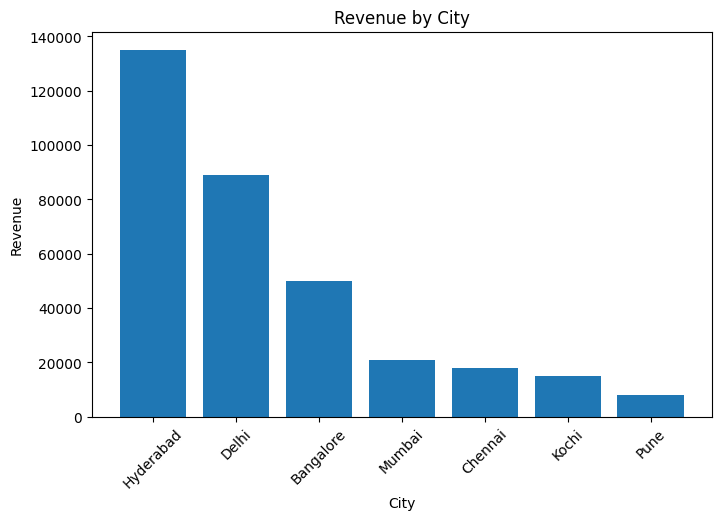

In [0]:
city_rev = full_df.groupBy('city') \
    .agg(sum('revenue').alias('total_revenue')) \
    .orderBy(desc('total_revenue'))

city_pd = city_rev.toPandas()

plt.figure(figsize=(8,5))
plt.bar(city_pd['city'], city_pd['total_revenue'])
plt.xlabel('City')
plt.ylabel('Revenue')
plt.title('Revenue by City')
plt.xticks(rotation=45)
plt.show()

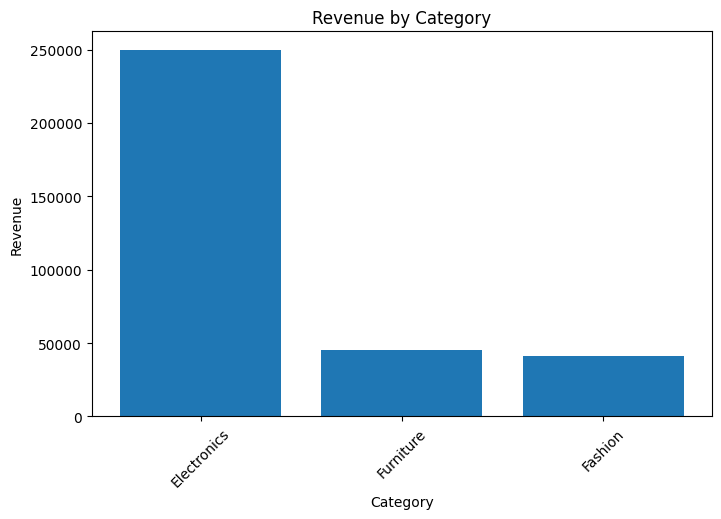

In [0]:
category_rev = full_df.groupBy('category') \
    .agg(sum('revenue').alias('total_revenue')) \
    .orderBy(desc('total_revenue'))

category_pd = category_rev.toPandas()

plt.figure(figsize=(8,5))
plt.bar(category_pd['category'], category_pd['total_revenue'])
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.title('Revenue by Category')
plt.xticks(rotation=45)
plt.show()

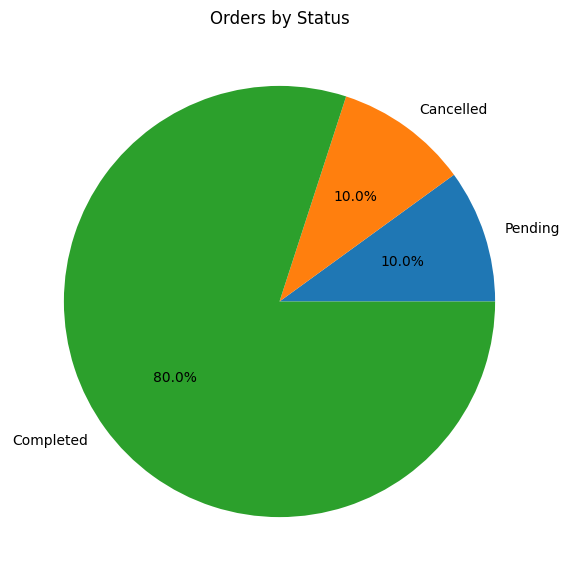

In [0]:
status_df = full_df.groupBy('status') \
    .agg(count('*').alias('orders'))

status_pd = status_df.toPandas()

plt.figure(figsize=(7,7))
plt.pie(
    status_pd['orders'],
    labels=status_pd['status'],
    autopct='%1.1f%%'
)
plt.title('Orders by Status')
plt.show()

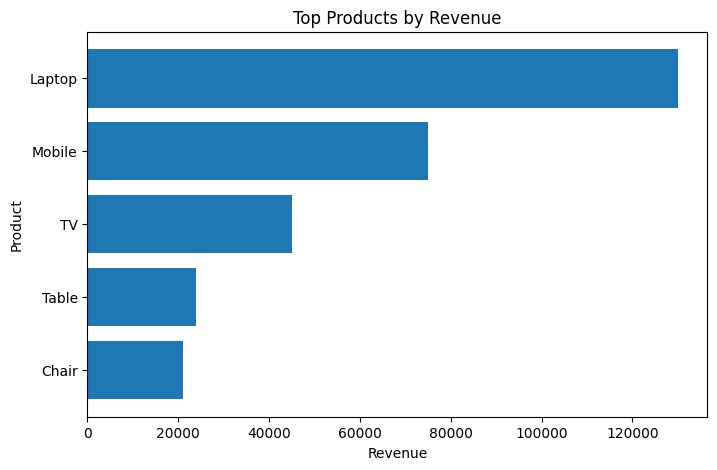

In [0]:
top_products = full_df.groupBy(
    'product_name'
).agg(
    sum('revenue').alias('total_revenue')
).orderBy(
    desc('total_revenue')
).limit(5)

top_products_pd = top_products.toPandas()

plt.figure(figsize=(8,5))
plt.barh(
    top_products_pd['product_name'],
    top_products_pd['total_revenue']
)

plt.xlabel('Revenue')
plt.ylabel('Product')
plt.title('Top Products by Revenue')
plt.gca().invert_yaxis()

plt.show()

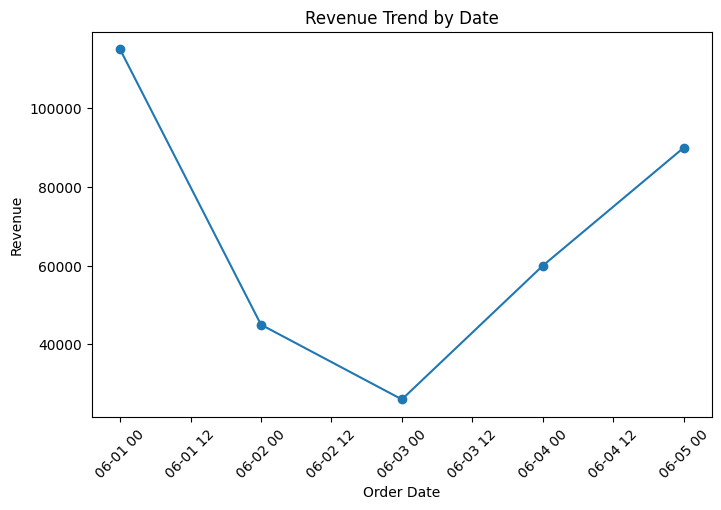

In [0]:
revenue_trend = full_df.groupBy(
    'order_date'
).agg(
    sum('revenue').alias('daily_revenue')
).orderBy('order_date')

trend_pd = revenue_trend.toPandas()

plt.figure(figsize=(8,5))
plt.plot(
    trend_pd['order_date'],
    trend_pd['daily_revenue'],
    marker='o'
)

plt.xlabel('Order Date')
plt.ylabel('Revenue')
plt.title('Revenue Trend by Date')
plt.xticks(rotation=45)

plt.show()

In [0]:
full_df.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("customer_managed")

In [0]:
%sql
SELECT * FROM customer_managed;

customer_id,product_id,customer_name,city,state,customer_type,order_id,order_date,quantity,status,product_name,category,unit_price,preferred_channel,tier,points,revenue,order_month,customer_segment
C101,P101,Rahul Sharma,Hyderabad,Telangana,Premium,O1001,2026-06-01,1,Completed,Laptop,Electronics,65000,Online,Gold,1200,65000,6,High Value
C102,P102,Priya Reddy,Bangalore,Karnataka,Regular,O1002,2026-06-01,2,Completed,Mobile,Electronics,25000,Store,Silver,700,50000,6,Standard Value
C103,P103,Amit Kumar,Mumbai,Maharashtra,Regular,O1003,2026-06-02,3,Pending,Chair,Furniture,7000,null,null,null,21000,6,Standard Value
C104,P104,Sneha Patel,Delhi,Delhi,Premium,O1004,2026-06-02,2,Completed,Table,Furniture,12000,Online,Platinum,2200,24000,6,High Value
C105,P105,Farhan Ali,Chennai,Tamil Nadu,Regular,O1005,2026-06-03,4,Cancelled,Shoes,Fashion,4500,null,null,null,18000,6,Standard Value
C106,P106,Neha Singh,Pune,Maharashtra,Premium,O1006,2026-06-03,1,Completed,Watch,Fashion,8000,null,null,null,8000,6,High Value
C107,P107,Arjun Verma,Hyderabad,Telangana,Regular,O1007,2026-06-04,1,Completed,TV,Electronics,45000,null,null,null,45000,6,Standard Value
C108,P108,Meera Nair,Kochi,Kerala,Premium,O1008,2026-06-04,5,Completed,Bag,Fashion,3000,Mobile App,Gold,1500,15000,6,High Value
C101,P102,Rahul Sharma,Hyderabad,Telangana,Premium,O1009,2026-06-05,1,Completed,Mobile,Electronics,25000,Online,Gold,1200,25000,6,High Value
C104,P101,Sneha Patel,Delhi,Delhi,Premium,O1010,2026-06-05,1,Completed,Laptop,Electronics,65000,Online,Platinum,2200,65000,6,High Value


In [0]:
full_df.write \
    .format("delta") \
    .mode("overwrite") \
    .save("/Volumes/capstone_05/default/capstone_vol_02/external/customer_data")

In [0]:
%sql
CREATE TABLE customer_external
USING DELTA
LOCATION 'cloud storage url required';

---------------------------------------------------------------------------
AnalysisException                         Traceback (most recent call last)
File <command-4904072386937044>, line 1
----> 1 get_ipython().run_cell_magic('sql', '', "CREATE TABLE customer_external\nUSING DELTA\nLOCATION '/Volumes/capstone_05/default/capstone_vol_02/external/customer_data';\n")

File /databricks/python/lib/python3.12/site-packages/IPython/core/interactiveshell.py:2541, in InteractiveShell.run_cell_magic(self, magic_name, line, cell)
   2539 with self.builtin_trap:
   2540     args = (magic_arg_s, cell)
-> 2541     result = fn(*args, **kwargs)
   2543 # The code below prevents the output from being displayed
   2544 # when using magics with decorator @output_can_be_silenced
   2545 # when the last Python token in the expression is a ';'.
   2546 if getattr(fn, magic.MAGIC_OUTPUT_CAN_BE_SILENCED, False):

File /databricks/python_shell/lib/dbruntime/sql_magic/sql_magic.py:213, in SqlMagic.sql(self, 

In [0]:
full_df.createOrReplaceTempView("customer_temp")

In [0]:
%sql
CREATE OR REPLACE TABLE customer_external
USING DELTA
AS
SELECT *
FROM customer_temp;

num_affected_rows,num_inserted_rows


In [0]:
full_df.createOrReplaceGlobalTempView("customer_global_temp")

---------------------------------------------------------------------------
AnalysisException                         Traceback (most recent call last)
File <command-4904072386937047>, line 1
----> 1 full_df.createOrReplaceGlobalTempView("customer_global_temp")

File /databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/dataframe.py:2129, in DataFrame.createOrReplaceGlobalTempView(self, name)
   2125 def createOrReplaceGlobalTempView(self, name: str) -> None:
   2126     command = plan.CreateView(
   2127         child=self._plan, name=name, is_global=True, replace=True
   2128     ).command(session=self._session.client)
-> 2129     _, _, ei = self._session.client.execute_command(command, self._plan.observations)
   2130     self._execution_info = ei

File /databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/client/core.py:1538, in SparkConnectClient.execute_command(self, command, observations, extra_request_metadata)
   1536     req.user_context.user_id = 

In [0]:
#global_temp need to have a group to know which group has visibility. 

  File <command-4904072386937049>, line 1
    global_temp need to have a group to know which group has visibility.
                ^
SyntaxError: invalid syntax


In [0]:
%sql
SELECT * FROM global_temp.customer_global_temp;

---------------------------------------------------------------------------
AnalysisException                         Traceback (most recent call last)
File <command-4904072386937048>, line 1
----> 1 get_ipython().run_cell_magic('sql', '', 'SELECT * FROM global_temp.customer_global_temp;\n')

File /databricks/python/lib/python3.12/site-packages/IPython/core/interactiveshell.py:2541, in InteractiveShell.run_cell_magic(self, magic_name, line, cell)
   2539 with self.builtin_trap:
   2540     args = (magic_arg_s, cell)
-> 2541     result = fn(*args, **kwargs)
   2543 # The code below prevents the output from being displayed
   2544 # when using magics with decorator @output_can_be_silenced
   2545 # when the last Python token in the expression is a ';'.
   2546 if getattr(fn, magic.MAGIC_OUTPUT_CAN_BE_SILENCED, False):

File /databricks/python_shell/lib/dbruntime/sql_magic/sql_magic.py:213, in SqlMagic.sql(self, line, cell)
    206 except BaseException as e:
    207     self.driver_activi

In [0]:
"""
Managed tables:
* Available across notebooks and sessions (subject to permissions).
* Exist until explicitly dropped.

External tables:
* Available across notebooks and sessions (subject to permissions).
* Exist until explicitly dropped.

Temporary views:
* Available only within the current Spark session/notebook.
* Removed automatically when the session ends.

Global temporary views:
* Available across notebooks attached to the same cluster/application.
* Removed when the Spark application or cluster terminates.
"""

'\nManaged tables:\n* Available across notebooks and sessions (subject to permissions).\n* Exist until explicitly dropped.\n\nExternal tables:\n* Available across notebooks and sessions (subject to permissions).\n* Exist until explicitly dropped.\n\nTemporary views:\n* Available only within the current Spark session/notebook.\n* Removed automatically when the session ends.\n\nGlobal temporary views:\n* Available across notebooks attached to the same cluster/application.\n* Removed when the Spark application or cluster terminates.\n'